<a href="https://colab.research.google.com/github/akshita-singh-2808/airlines_churn_prediction/blob/main/airlines_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
dictionary= pd.read_csv("Airline Loyalty Data Dictionary.csv")
activity = pd.read_csv("Customer Flight Activity.csv")
loyalty = pd.read_csv("Customer Loyalty History.csv")
calendar = pd.read_csv("Calendar.csv")

In [ ]:
loyalty

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,NaN,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN


In [ ]:
loyalty.isnull().sum()

,0
Loyalty Number,0
Country,0
Province,0
City,0
Postal Code,0
Gender,0
Education,0
Salary,4238
Marital Status,0
Loyalty Card,0


# **Phase 1**
The problem — 4,258 records with broken salary

4,238 rows had NaN (blank salary)
20 rows had negative salary (e.g. –$58,486) — impossible, clearly a data entry mistake (someone probably typed without the dollar sign, or it was a system glitch flipping the sign)

In [ ]:
loyalty.loc[loyalty['Salary'] < 0, 'Salary'] = np.nan   # negatives → blank


In [ ]:
loyalty['Salary_Was_Imputed'] = loyalty['Salary'].isnull()    #if the salary is null it will show true else false

In [ ]:
loyalty['Salary_Imputed'] = loyalty.groupby(     #calculate the median salary using loyalty card and education as group
    ['Education', 'Loyalty Card']
)['Salary'].transform(
    lambda x: x.fillna(x.median())
)


In [ ]:
loyalty['Salary_Imputed'] = loyalty['Salary_Imputed'].fillna(
    loyalty['Salary'].median()
)

11 customer records were identified where the cancellation month was the same as or earlier than the enrollment month. Since the dataset only contains month-level granularity (not exact dates), these records are considered ambiguous for churn labeling. For example, a customer could realistically enroll on 10-Dec-2017 and cancel on 25-Dec-2017, which would still appear as the same month in the dataset. However, because exact dates are unavailable, it is impossible to distinguish valid same-month cancellations from logically inconsistent cases. To maintain cleaner and more reliable churn labels for modeling, these 11 records were excluded from the training dataset.

In [ ]:
loyalty['enroll_ym'] = loyalty['Enrollment Year'] * 100 + loyalty['Enrollment Month']  #this is done so that dates can be comparable

In [ ]:
cancelled = loyalty[loyalty['Cancellation Year'].notna()].copy()  #this keeps only cancelled customers

In [ ]:
cancelled['cancel_ym'] = cancelled['Cancellation Year'] * 100 + cancelled['Cancellation Month']

In [ ]:
cancelled['is_bad'] = cancelled['cancel_ym'] <= cancelled['enroll_ym']  #impossible conditions - when the cancellation is done before enrollment


In [ ]:
print(cancelled[cancelled['is_bad']][['Loyalty Number','Enrollment Year',
      'Enrollment Month','Cancellation Year','Cancellation Month']])


       Loyalty Number  Enrollment Year  Enrollment Month  Cancellation Year  \
1461           607266             2016                 3             2016.0   
1756           939593             2013                 9             2013.0   
1957           140042             2014                 8             2014.0   
3145           488724             2013                 1             2013.0   
3157           160779             2017                12             2017.0   
5732           472283             2014                 4             2014.0   
5804           239221             2014                 5             2014.0   
8860           896685             2016                12             2016.0   
10755          304528             2018                 8             2018.0   
12147          871455             2017                 6             2017.0   
13498          110603             2017                10             2017.0   

       Cancellation Month  
1461                  3

In [ ]:
# Remove bad customers
loyalty_clean = loyalty[
    ~loyalty['Loyalty Number'].isin(
        cancelled.loc[cancelled['is_bad'], 'Loyalty Number']
    )
]

In [ ]:
activity["activity_ym"]=activity["Year"]*100 + activity["Month"]

In [ ]:
active_flights=activity[activity["Total Flights"]>0]

In [ ]:
last_active = active_flights.groupby('Loyalty Number')['activity_ym'].max().reset_index()

In [ ]:
last_active.columns = ['Loyalty Number', 'Last_Active_YM']
last_active

,Loyalty Number,Last_Active_YM
0,100018,201812
1,100102,201812
2,100140,201811
3,100214,201812
4,100272,201811
...,...,...
15162,999788,201710
15163,999902,201810
15164,999940,201812
15165,999982,201811


In [ ]:
loyalty_clean= loyalty_clean.merge(last_active, on='Loyalty Number', how='left')

In [ ]:
loyalty_clean

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Salary_Was_Imputed,Salary_Imputed,enroll_ym,Last_Active_YM
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,False,83236.0,201602,201812.0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,True,73510.0,201603,201812.0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,True,73510.0,201407,201801.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN,True,73510.0,201302,201812.0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,False,103495.0,201410,201812.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16721,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN,True,73510.0,201212,201812.0
16722,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN,False,89210.0,201409,201812.0
16723,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN,True,73510.0,201403,201812.0
16724,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,NaN,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN,True,71412.0,201804,201812.0


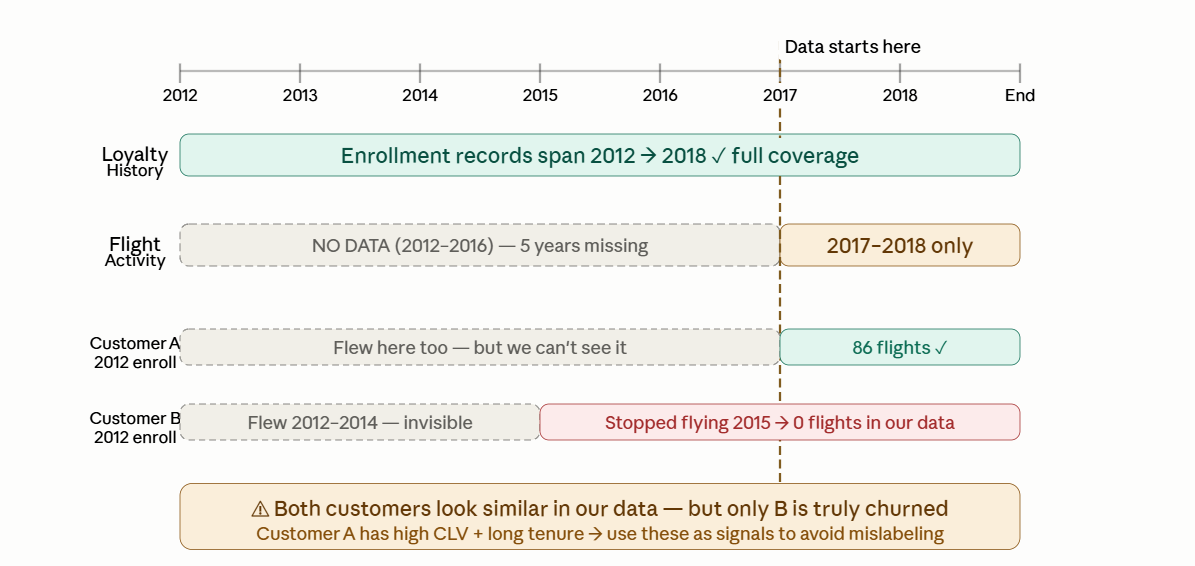

In [ ]:
from IPython.display import Image, display

display(Image('/content/flight_data_gap.png'))